# INFO 5613 – Class 23: Weighted networks

[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Import libraries

In [1]:
# Load networkx for working with network data
import networkx as nx

# Load numpy for working with numerical data
import numpy as np

# Load pandas for working with tabular data
import pandas as pd
pd.options.display.max_columns = 100

# Load visualization libraries
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sb

import requests
from itertools import combinations


# Define a formatting string we can use to print the number of nodes and edges
node_edge_s = "There are {0:,} nodes and {1:,} edges in the network."

## Examples of weighted networks

### Movie collaborations

In [2]:
actors_g = nx.read_gexf('imdb_actors_projection.gexf')
print(node_edge_s.format(actors_g.number_of_nodes(),actors_g.number_of_edges()))

There are 3,833 nodes and 36,791 edges in the network.


In [3]:
list(actors_g.edges(data=True))[:5]

[('Yoo Ji-tae', 'Seung-shin Lee', {'id': '0', 'weight': 1.0}),
 ('Yoo Ji-tae', 'Jung Ae Kwak', {'id': '1', 'weight': 1.0}),
 ('Yoo Ji-tae', 'Kang Hye-jeong', {'id': '2', 'weight': 1.0}),
 ('Yoo Ji-tae', 'Kim Byeong-Ok', {'id': '3', 'weight': 1.0}),
 ('Yoo Ji-tae', 'Choi Min-sik', {'id': '4', 'weight': 1.0})]

### Scene co-occurrences

In [8]:
# Get the data
got_episodes_json = requests.get('https://raw.githubusercontent.com/jeffreylancaster/game-of-thrones/master/data/episodes.json').json()

# Inspect the data
got_episodes_json['episodes'][0]['scenes']

[{'sceneStart': '0:00:40',
  'sceneEnd': '0:01:45',
  'location': 'The Wall',
  'subLocation': 'Castle Black',
  'characters': [{'name': 'Gared'},
   {'name': 'Waymar Royce'},
   {'name': 'Will'}]},
 {'sceneStart': '0:01:45',
  'sceneEnd': '0:03:24',
  'location': 'North of the Wall',
  'subLocation': 'The Haunted Forest',
  'characters': [{'name': 'Gared'},
   {'name': 'Waymar Royce'},
   {'name': 'Will'}]},
 {'sceneStart': '0:03:24',
  'sceneEnd': '0:03:31',
  'location': 'North of the Wall',
  'subLocation': 'The Haunted Forest',
  'characters': [{'name': 'Will'},
   {'name': 'Wight Wildling Girl', 'alive': False}]},
 {'sceneStart': '0:03:31',
  'sceneEnd': '0:03:38',
  'location': 'North of the Wall',
  'subLocation': 'The Haunted Forest',
  'characters': [{'name': 'Will'}]},
 {'sceneStart': '0:03:38',
  'sceneEnd': '0:03:44',
  'location': 'North of the Wall',
  'subLocation': 'The Haunted Forest',
  'characters': []},
 {'sceneStart': '0:03:44',
  'sceneEnd': '0:05:36',
  'locatio

In [6]:
# Start with an empty undirected graph
got_g = nx.Graph()

# For each scene and its list of character combinations
for _episode in got_episodes_json['episodes']:
    
    for _scene in _episode['scenes']:
    
        _characters = [c.get('name') for c in _scene['characters']]
        
        for _c0 in _characters:
            for _c1 in _characters:
                if _c0 != _c1:
                    if got_g.has_edge(_c0,_c1):
                        got_g[_c0][_c1]['weight'] += 1
                    else:
                        got_g.add_edge(_c0,_c1,weight=1)

nx.write_gexf(got_g,'gameofthrones.gexf')                        

print(node_edge_s.format(got_g.number_of_nodes(),got_g.number_of_edges()))

There are 576 nodes and 4,236 edges in the network.


In [7]:
list(got_g.edges(data=True))[:5]

[('Gared', 'Waymar Royce', {'weight': 10}),
 ('Gared', 'Will', {'weight': 8}),
 ('Gared', 'White Walker', {'weight': 4}),
 ('Waymar Royce', 'Will', {'weight': 6}),
 ('Waymar Royce', 'White Walker', {'weight': 2})]

### Airport traffic

In [9]:
airports_df = pd.read_csv('2022_airport_traffic.csv')
airports_df.head()

,Origin,Destination,Passengers
0,"Aberdeen, SD","Bullhead City, AZ",120
1,"Aberdeen, SD","Minneapolis, MN",23378
2,"Aberdeen, SD","Wichita, KS",8
3,"Abilene, TX","Austin, TX",53
4,"Abilene, TX","Birmingham, AL",118


Explore the distribution of edge weights.

Text(0.5, 1.0, 'Log-binned & scaled histogram')

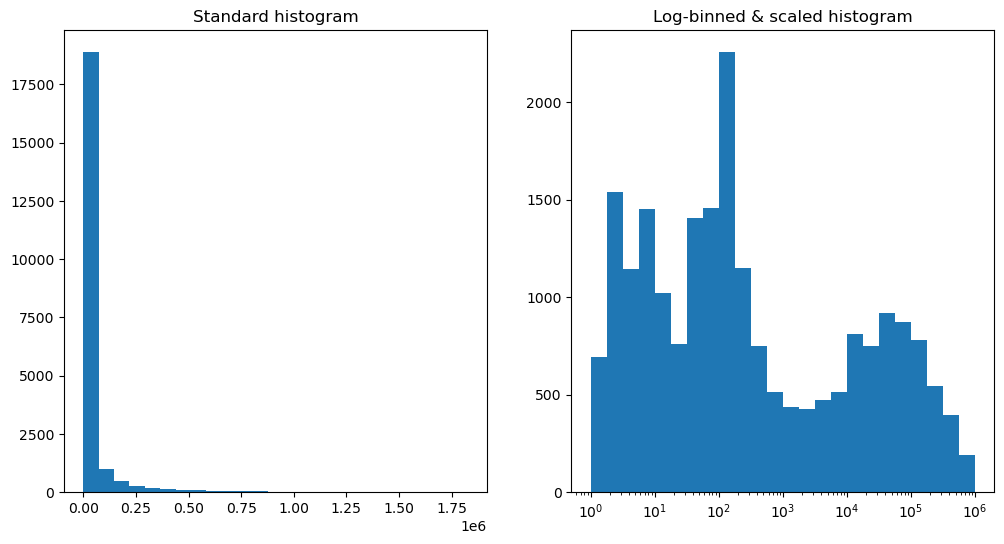

In [10]:
f,axs = plt.subplots(1,2,figsize=(12,6))

airports_df['Passengers'].hist(ax = axs[0],bins=25)
airports_df['Passengers'].hist(ax = axs[1],bins=np.logspace(0,6,25))

# Log-scale x-axis
axs[1].set_xscale('log')

# Turn off gridlines
axs[0].grid(None)
axs[1].grid(None)

axs[0].set_title('Standard histogram')
axs[1].set_title('Log-binned & scaled histogram')

What are the top routes?

In [13]:
airports_df.sort_values(['Passengers'],ascending=False).head(10)

,Origin,Destination,Passengers
11467,"Miami, FL","New York, NY",1825692
13085,"New York, NY","Miami, FL",1824681
3916,"Chicago, IL","New York, NY",1412727
13024,"New York, NY","Chicago, IL",1407199
902,"Atlanta, GA","New York, NY",1396760
3809,"Chicago, IL","Denver, CO",1385580
13002,"New York, NY","Atlanta, GA",1376663
13076,"New York, NY","Los Angeles, CA",1356937
5367,"Denver, CO","Chicago, IL",1353281
10675,"Los Angeles, CA","New York, NY",1350284


Convert into a directed graph.

In [14]:
airports_g = nx.from_pandas_edgelist(
    df = airports_df,
    source = 'Origin',
    target = 'Destination',
    edge_attr = ['Passengers'],
    create_using = nx.DiGraph
)

nx.write_gexf(airports_g,'airports.gexf')

print(node_edge_s.format(airports_g.number_of_nodes(),airports_g.number_of_edges()))

There are 1,102 nodes and 21,296 edges in the network.


### Correlation network

In [15]:
terpene_df = pd.read_csv('spearman_corr.csv',index_col=0)
terpene_df.head()

,tot_ocimene,bisabolol,g_terpinene,tot_nerolidol_ct,humulene,caryophyllene,limonene,linalool,camphene,myrcene,b_pinene,a_terpinene,terpinolene,a_pinene
tot_ocimene,1.000000,-0.021387,0.312405,0.320643,-0.170736,-0.183228,-0.206383,-0.189665,-0.003239,0.058477,0.221222,0.291474,0.306982,0.312837
bisabolol,-0.021387,1.000000,-0.189840,0.151752,0.250869,0.342997,0.156308,0.202797,0.232914,0.010244,-0.066260,-0.272361,-0.032561,-0.104065
g_terpinene,0.312405,-0.189840,1.000000,-0.066546,-0.086046,-0.188432,-0.159523,-0.164640,-0.031755,-0.051680,0.179508,0.759764,0.507568,0.098272
tot_nerolidol_ct,0.320643,0.151752,-0.066546,1.000000,0.072013,0.107731,0.096590,0.037146,0.086374,0.063562,0.067772,-0.126229,-0.003895,0.044693
humulene,-0.170736,0.250869,-0.086046,0.072013,1.000000,0.875002,0.343754,0.325228,0.155008,-0.113490,-0.080852,-0.084099,-0.004559,-0.232135


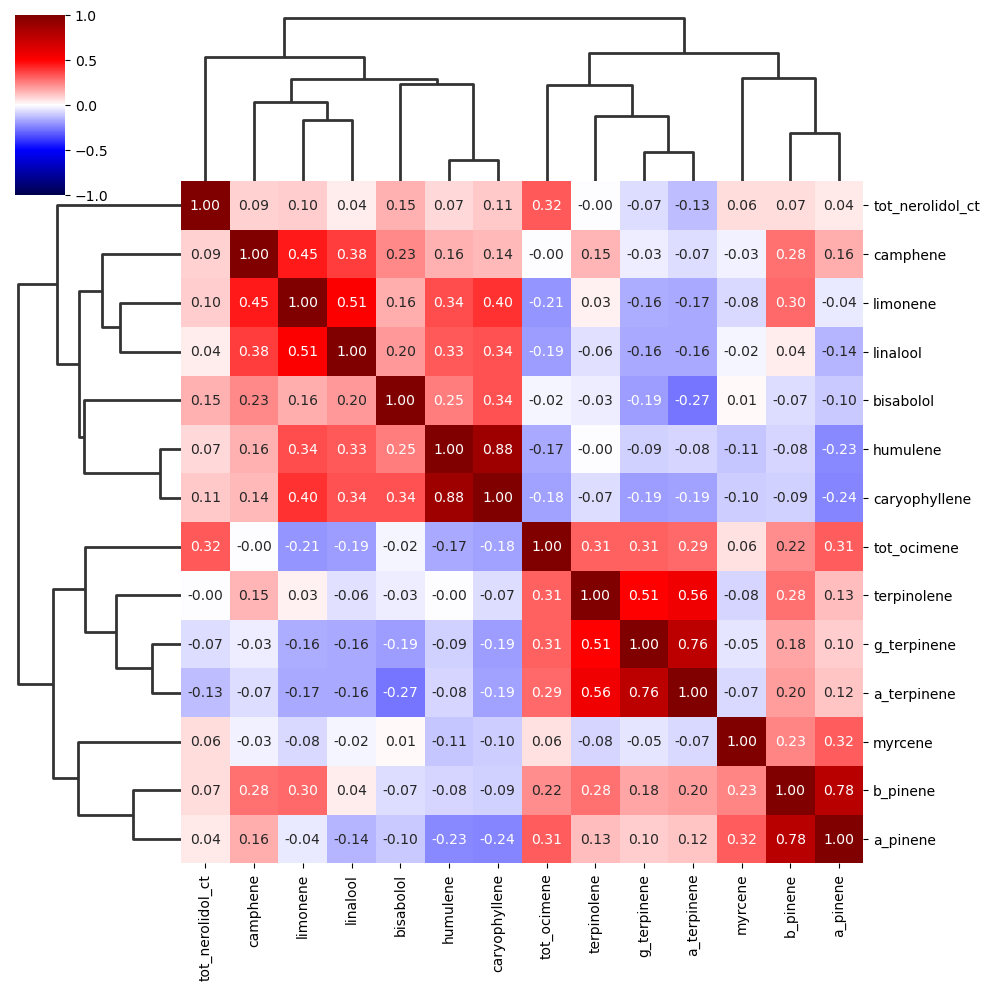

In [16]:
g = sb.clustermap(terpene_df,
                  cmap='seismic',
                  vmin=-1,
                  vmax=1,
                  center=0,
                  annot=True,
                  fmt='.2f',
                  tree_kws={'linewidth':2}
             )

In [17]:
terpene_g = nx.from_numpy_matrix(
    terpene_df.values,
    create_using=nx.Graph
)

terpene_gc = terpene_g.copy()

for i,j,d in terpene_g.edges(data=True):
    if i == j:
        terpene_gc.remove_edge(i,j)
    elif d['weight'] <= .10:
        terpene_gc.remove_edge(i,j)

terpene_gc.remove_nodes_from(list(nx.isolates(terpene_gc)))
print(node_edge_s.format(terpene_gc.number_of_nodes(),terpene_gc.number_of_edges()))

pos = nx.layout.rescale_layout_dict(nx.layout.spring_layout(terpene_gc,iterations=1000),1.3)

There are 14 nodes and 38 edges in the network.


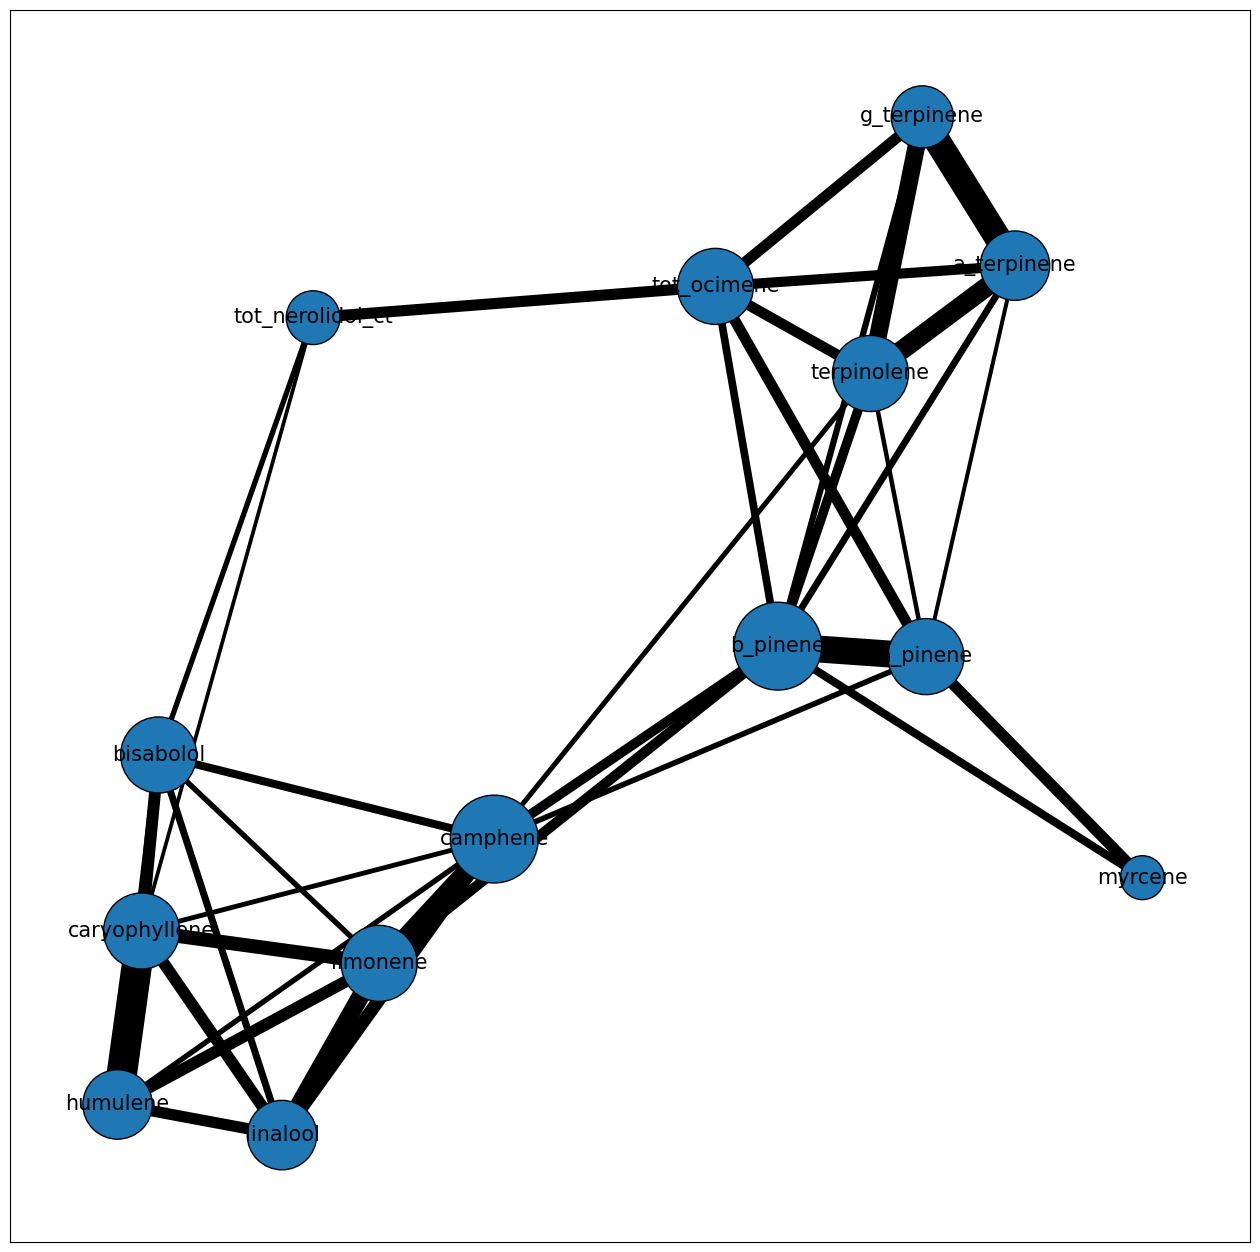

In [18]:
deg = nx.degree(terpene_gc)

tot_terp_cols = [
    'tot_ocimene', 'bisabolol', 'g_terpinene', 'tot_nerolidol_ct','humulene',
    'caryophyllene', 'limonene', 'linalool', 'camphene', 'myrcene', 'b_pinene',
    'a_terpinene', 'terpinolene', 'a_pinene'
]

label_map = {_p:tot_terp_cols[_p] for _p in terpene_gc.nodes()}

f,ax = plt.subplots(figsize=(16, 16))

nx.draw_networkx_edges(
    terpene_gc, 
    pos,
    width = [d['weight']*25 for i,j,d in terpene_gc.edges(data=True)],
    ax=ax
)

nx.draw_networkx_nodes(
    terpene_gc,
    pos,
    node_size=[v*500 for v in dict(deg).values()],
    edgecolors='k',
    ax=ax
)

nx.draw_networkx_labels(
    terpene_gc,
    pos,
    labels=label_map,
    font_size=15,
    ax=ax
);

### S&P 500 prices

In [19]:
sp500_df = pd.read_csv('sp500_closes.csv',parse_dates=['Date']).set_index('Date')
sp500_df.head()

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALK,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,ANSS,ANTM,AON,AOS,APA,APD,APH,APTV,ARE,ATO,ATVI,AVB,AVGO,AVY,...,UAA,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VFC,VIAC,VLO,VMC,VNO,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAT,WBA,WDC,WEC,WELL,WFC,WHR,WLTW,WM,WMB,WMT,WRB,WRK,WST,WU,WY,WYNN,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-11-01,156.060547,19.770000,218.664673,147.884644,110.504662,120.843826,349.989990,126.812050,350.537811,640.200012,171.844757,62.344643,218.074524,315.010010,82.137299,81.542847,24.674896,53.483608,58.795319,158.844376,160.514023,105.389999,254.201767,661.460022,54.709999,120.180786,127.964241,138.341553,11.475812,125.230003,133.157089,203.062408,299.545685,275.550110,165.905502,102.142502,376.440002,NaN,304.535889,73.323906,26.731989,296.519104,76.118401,175.729996,199.451523,90.696220,78.881119,228.343750,512.585999,215.887878,...,21.980000,48.049999,54.693203,124.103195,365.130005,448.287903,234.448578,203.140320,383.329987,58.525578,210.494385,70.400925,NaN,74.894379,186.102554,40.062027,207.574463,223.070007,185.399994,53.084862,13.296572,50.201942,89.821594,364.600006,44.794609,54.180000,86.994019,80.088531,50.329285,206.914154,NaN,156.807678,27.084158,147.434158,51.961823,46.419434,425.525055,17.737162,35.025787,93.690002,62.751179,NaN,62.288681,57.415062,127.673225,124.220161,140.373474,542.590027,62.106541,212.044250
2021-11-02,156.845520,19.830000,220.277145,148.936996,112.160172,123.195557,349.760010,125.602341,356.634613,640.400024,174.741714,62.109421,221.049088,314.920013,82.186028,81.705673,24.674896,53.727291,58.590183,159.090347,161.077118,105.129997,258.324677,667.059998,54.450001,121.805779,129.274734,140.027328,11.610369,127.629997,138.918457,207.389084,301.602905,276.087372,165.637497,122.967499,384.170013,NaN,302.401978,76.916489,26.850054,296.608673,76.988777,174.610001,199.860168,91.427322,77.211052,228.829361,521.341797,212.874649,...,25.600000,47.980000,54.862164,122.116432,371.859985,446.244476,235.408081,201.445068,386.190002,58.602612,207.205063,69.380478,NaN,72.820915,192.877655,39.601650,207.942047,225.710007,181.399994,52.602623,13.306195,49.841667,90.506264,348.880005,45.201664,55.029999,87.523643,79.544571,49.930229,207.869293,NaN,158.727402,26.941807,147.365265,52.974323,45.788074,436.782928,17.255480,34.239643,91.550003,62.955479,NaN,61.519917,58.136208,127.455940,122.148682,140.257935,585.549988,61.854980,210.654449
2021-11-03,157.193298,20.629999,224.347183,150.396378,113.161163,126.236084,358.019989,126.576004,357.226562,655.179993,175.586258,63.608978,221.618469,308.369995,82.049591,81.351257,24.606812,54.643547,59.664700,162.819183,159.358185,110.870003,260.242126,673.609985,55.930000,122.720436,127.491287,141.554428,11.821816,130.529999,140.080658,211.134995,303.924652,274.084930,169.199997,128.449997,384.859985,NaN,292.685181,76.945930,27.184570,300.638702,77.512985,178.119995,201.903320,91.008156,66.355576,229.926910,526.486572,213.918457,...,26.540001,49.049999,54.832348,124.013786,381.779999,451.466644,234.448578,204.912628,381.269989,59.536633,206.174698,71.613907,NaN,72.840111,192.867752,40.863087,212.889496,226.089996,189.070007,52.901608,13.373543,50.192463,91.865692,347.510010,46.602676,55.770000,86.541428,80.447937,50.611542,210.397125,NaN,157.240860,26.856396,147.818024,52.961338,47.031361,436.962372,17.482151,36.247616,93.480003,61.778290,NaN,60.675228,58.501717,124.068298,121.785446,143.213867,578.489990,63.644928,209.592255
2021-11-04,156.646790,20.629999,223.502106,149.870193,112.670288,124.750259,363.070007,126.959572,361.863281,674.080017,177.481567,62.952316,222.050415,318.970001,82.225014,80.355087,24.431744,54.292641,58.990685,161.579514,158.834595,109.660004,270.882294,679.260010,55.730000,113.943573,129.156479,148.872620,11.687259,137.

In [20]:
sp500_corr_df = sp500_df.corr()
sp500_corr_df.head()

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALK,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,ANSS,ANTM,AON,AOS,APA,APD,APH,APTV,ARE,ATO,ATVI,AVB,AVGO,AVY,...,UAA,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VFC,VIAC,VLO,VMC,VNO,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAT,WBA,WDC,WEC,WELL,WFC,WHR,WLTW,WM,WMB,WMT,WRB,WRK,WST,WU,WY,WYNN,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
A,1.000000,0.549088,0.672195,0.501457,-0.699467,-0.613032,0.779905,0.681341,0.805772,0.769221,0.712033,-0.557820,0.353506,0.931468,-0.303906,-0.577853,0.459147,0.058157,0.227270,-0.461963,0.004247,0.484404,0.349766,0.786539,0.502133,-0.528705,0.765208,0.745324,-0.268531,0.732243,0.877491,-0.493023,0.744189,0.355351,0.730781,0.749820,0.819769,NaN,0.360803,0.795327,-0.565042,0.870650,0.920053,0.847439,0.684808,-0.623738,-0.662481,0.486017,0.412741,0.850501,...,0.748282,0.423796,0.497300,0.322464,0.043336,-0.380083,0.420963,0.582191,0.807180,0.615506,0.336665,0.647530,NaN,-0.659483,0.858866,0.461747,0.727901,0.846359,-0.633731,-0.091442,0.593237,0.145493,0.542602,0.532652,0.539196,0.391817,-0.413307,0.001424,0.599390,0.682668,NaN,0.213984,-0.649537,0.371986,-0.679489,0.167101,0.660109,0.123069,0.149884,0.757369,-0.421749,NaN,-0.597328,0.605711,0.930421,0.761645,0.551630,0.787890,0.532804,0.725685
AAL,0.549088,1.000000,0.836619,0.485374,-0.343284,-0.256053,0.608925,0.785206,0.752339,0.763388,0.681138,-0.383694,-0.110021,0.679997,0.073990,-0.280574,-0.065039,0.011091,0.668934,0.236263,-0.317251,0.796567,-0.168172,0.783446,0.879957,-0.198811,0.836283,0.813946,-0.012464,0.759581,0.693188,-0.485762,0.557379,0.435236,0.729268,0.524687,0.763786,NaN,0.492872,0.752205,-0.357052,0.546124,0.551516,0.781045,0.824504,-0.316963,-0.321598,0.746124,0.696860,0.591626,...,0.831870,0.921430,0.763458,0.690340,-0.089722,-0.506338,0.612571,0.551157,0.720578,0.813335,0.609034,0.795161,NaN,-0.541576,0.761017,0.812498,0.704226,0.697909,-0.695787,0.525164,0.684597,0.625013,0.498849,0.489361,0.778145,0.752146,-0.151231,0.585977,0.623799,0.777362,NaN,-0.103622,-0.306060,0.596296,-0.534228,0.794625,0.733935,0.690977,0.703698,0.766736,-0.119999,NaN,-0.664670,0.778005,0.491739,0.651303,0.862801,0.775481,0.675464,0.721616
AAP,0.672195,0.836619,1.000000,0.693471,-0.407756,-0.391382,0.656061,0.905042,0.900058,0.845707,0.698379,-0.538096,-0.068240,0.742503,-0.001417,-0.391422,-0.063520,0.059046,0.557732,0.043450,-0.330089,0.869028,-0.257257,0.871550,0.814234,-0.382790,0.907172,0.908678,-0.130229,0.848460,0.835875,-0.536821,0.628828,0.479500,0.822754,0.649147,0.877038,NaN,0.478461,0.919930,-0.572996,0.651912,0.722041,0.858652,0.920850,-0.382922,-0.385915,0.847214,0.764302,0.697164,...,0.889125,0.683923,0.875765,0.725859,-0.235687,-0.499841,0.721791,0.715791,0.715354,0.878320,0.647904,0.884587,NaN,-0.737304,0.865625,0.842703,0.808082,0.868121,-0.739036,0.416811,0.762472,0.662221,0.434889,0.586490,0.897813,0.749459,-0.209138,0.541444,0.739111,0.884885,NaN,-0.128696,-0.511539,0.578103,-0.710913,0.666773,0.863151,0.694590,0.701173,0.816834,-0.183798,NaN,-0.781478,0.875340,0.590472,0.788780,0.736556,0.892642,0.749664,0.869552
AAPL,0.501457,0.485374,0.693471,1.000000,-0.127958,-0.161651,0.469148,0.669940,0.733046,0.518380,0.549573,-0.213847,0.219733,0.463878,0.288971,-0.005312,0.183763,0.346170,0.462374,0.052529,0.049771,0.707833,-0.163602,0.588660,0.673092,-0.156043,0.525563,0.655595,-0.155402,0.614848,0.689749,-0.334253,0.578442,0.467304,0.749463,0.784301,0.648464,NaN,0.593781,0.655604,-0.438767,0.401401,0.701213,0.548484,0.750095,0.050559,-0.103431,0.780236,0.764157,0.518584,...,0.560783,0.332429,0.750208,0.554206,-0.057560,-0.052314,0.777140,0.774845,0.572949,0.611900,0.687930,0.588206,NaN,-0.555162,0.725081,0.609626,0.759435,0.754250,-0.341532,0.352319,0.433422,0.399975,0.434613,0.343596,0.591061,0.449265,0.109952,0.444407,0.658593,0.588677,NaN,0.168495,-0.281899,0.479112,-0.484729,0.413757,0.706921,0.560752,0.591365,0.597891,0.163320,NaN,-0.5100

/Users/briankeegan/opt/miniconda3/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


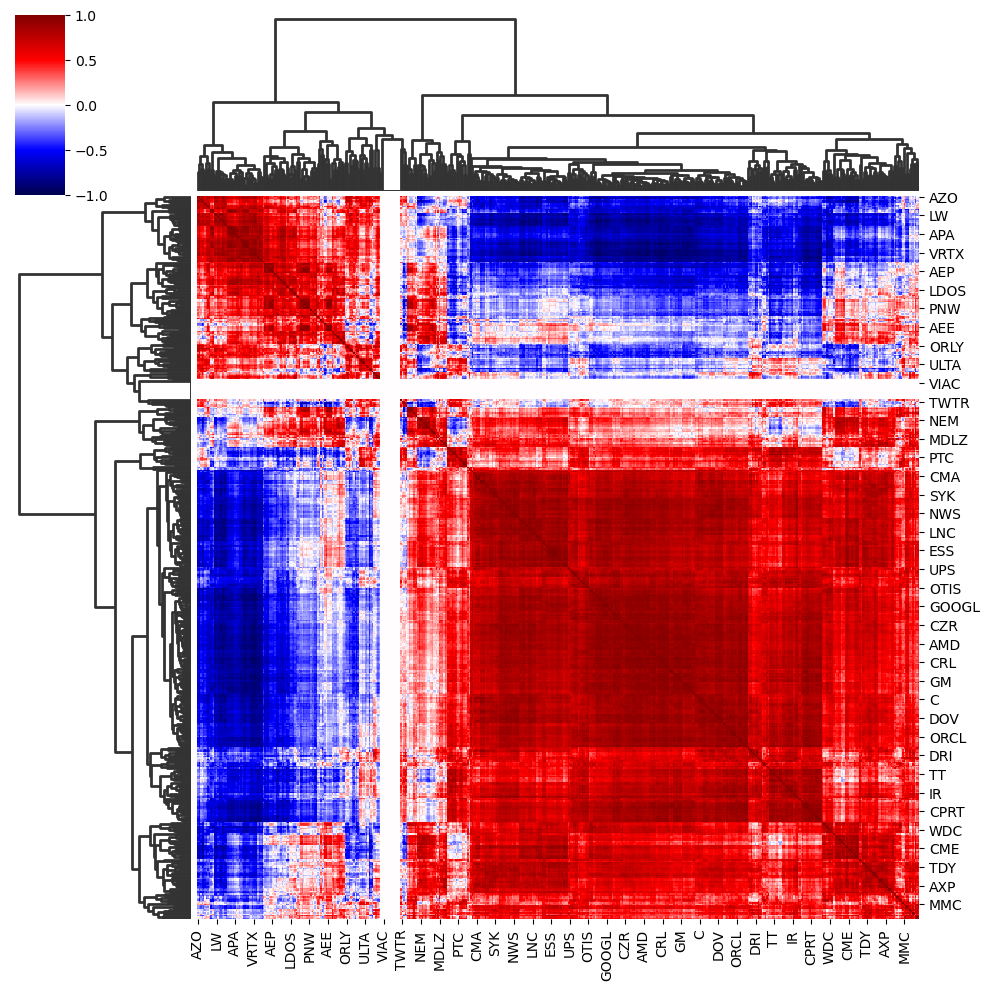

In [21]:
g = sb.clustermap(
    sp500_corr_df.fillna(0),
    cmap='seismic',
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    fmt='.2f',
    tree_kws={'linewidth':2}
)

In [22]:
_matrix = sp500_corr_df.fillna(0).values
np.fill_diagonal(_matrix,0)
sp500_corr_df2 = pd.DataFrame(_matrix,index=sp500_corr_df.index,columns=sp500_corr_df.columns)

sp500_g = nx.from_pandas_adjacency(
    sp500_corr_df2,
    create_using=nx.Graph
)

nx.write_gexf(sp500_g,'sp500_corr.gexf')

print(node_edge_s.format(sp500_g.number_of_nodes(),sp500_g.number_of_edges()))

There are 505 nodes and 120,295 edges in the network.


## Node strength

The strength of a node in a weighted network is the sum of its weights from all its neighbors.

* The weighted `.degree` is the sum of all the in and out neighbors
* The weighted `.in_degree` is the sum of only the in neighbors
* The weighted `.out_degree` is the sum of only the out neighbors

### Airport traffic

In [23]:
pd.Series(dict(airports_g.degree(weight='Passengers'))).sort_values(ascending=False).head(10)

Atlanta, GA              79886894
Chicago, IL              72995050
Denver, CO               62782903
Dallas/Fort Worth, TX    60537726
New York, NY             51134681
Los Angeles, CA          48261360
Las Vegas, NV            46389045
Phoenix, AZ              43332611
Orlando, FL              42927164
Charlotte, NC            42254315
dtype: int64

In [42]:
pd.Series(dict(airports_g.degree())).sort_values(ascending=False).head(10)

Chicago, IL              482
Denver, CO               453
Dallas/Fort Worth, TX    452
White Plains, NY         419
Washington, DC           413
Phoenix, AZ              400
Las Vegas, NV            395
Van Nuys, CA             394
Teterboro, NJ            383
Atlanta, GA              377
dtype: int64

In [24]:
pd.Series(dict(airports_g.in_degree(weight='Passengers'))).sort_values(ascending=False).head(10)

Atlanta, GA              39993660
Chicago, IL              36559191
Denver, CO               31410814
Dallas/Fort Worth, TX    30296674
New York, NY             25623866
Los Angeles, CA          24122369
Las Vegas, NV            23229206
Phoenix, AZ              21583336
Orlando, FL              21541078
Charlotte, NC            21164819
dtype: int64

In [25]:
pd.Series(dict(airports_g.out_degree(weight='Passengers'))).sort_values(ascending=False).head(10)

Atlanta, GA              39893234
Chicago, IL              36435859
Denver, CO               31372089
Dallas/Fort Worth, TX    30241052
New York, NY             25510815
Los Angeles, CA          24138991
Las Vegas, NV            23159839
Phoenix, AZ              21749275
Orlando, FL              21386086
Charlotte, NC            21089496
dtype: int64

### Exercise: Repeat for collaborations or co-occurrences

In [31]:
pd.Series(dict(got_g.degree())).sort_values(ascending=False).head(10)

Arya Stark            156
Tyrion Lannister      148
Sansa Stark           133
Jon Snow              122
Daenerys Targaryen    113
Jaime Lannister       112
Theon Greyjoy         108
Bran Stark            105
Sandor Clegane        103
Cersei Lannister       99
dtype: int64

In [30]:
pd.Series(dict(got_g.degree(weight='weight'))).sort_values(ascending=False).head(10)

Jon Snow              4128
Tyrion Lannister      3884
Daenerys Targaryen    3512
Sansa Stark           2484
Cersei Lannister      2278
Jaime Lannister       2154
Davos Seaworth        2144
Jorah Mormont         2106
Lord Varys            2016
Missandei             2014
dtype: int64

## Weight distribution

The distribution of edge weights in a network is often long-tailed.

In [32]:
list(airports_g.edges(data=True))[:5]

[('Aberdeen, SD', 'Bullhead City, AZ', {'Passengers': 120}),
 ('Aberdeen, SD', 'Minneapolis, MN', {'Passengers': 23378}),
 ('Aberdeen, SD', 'Wichita, KS', {'Passengers': 8}),
 ('Bullhead City, AZ', 'Aberdeen, SD', {'Passengers': 111}),
 ('Bullhead City, AZ', 'Abilene, TX', {'Passengers': 45})]

In [33]:
edge_passengers =  [attr_dict['Passengers'] for (source,destination,attr_dict) in airports_g.edges(data=True)]

edge_passengers_df = pd.Series(edge_passengers).value_counts().sort_index().reset_index()
edge_passengers_df.columns = ['Passengers','Count']

edge_passengers_df.head()

,Passengers,Count
0,1,695
1,2,996
2,3,544
3,4,677
4,5,466


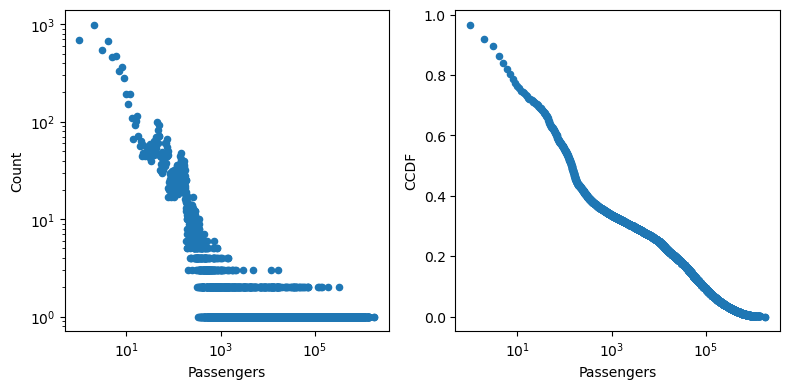

In [34]:
edge_passengers_df['CCDF'] = 1 - edge_passengers_df['Count'].cumsum()/edge_passengers_df['Count'].sum()

f,axs = plt.subplots(1,2,figsize=(8,4))
edge_passengers_df.plot.scatter(x='Passengers',y='Count',ax=axs[0])
edge_passengers_df.plot.scatter(x='Passengers',y='CCDF',ax=axs[1])

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')

f.tight_layout()

## Filtering edges

In particularly dense weighted networks, the edges can be removed for the purposes of visualization.

The first strategy is to apply a "global threshold" and remove all edges below some cut-off value.

In [36]:
airports_copy = nx.DiGraph()

for i,j,d in airports_g.edges(data=True):
    if d['Passengers'] > 10000:
        airports_copy.add_edge(i,j)

print(node_edge_s.format(airports_g.number_of_nodes(),airports_g.number_of_edges()))
print(node_edge_s.format(airports_copy.number_of_nodes(),airports_copy.number_of_edges()))

There are 1,102 nodes and 21,296 edges in the network.
There are 370 nodes and 5,303 edges in the network.


What's the right value to choose? Ideally a threshold that keeps all or most of the nodes, preserves the number of components, *etc*.

Text(0.5, 0, 'Threshold')

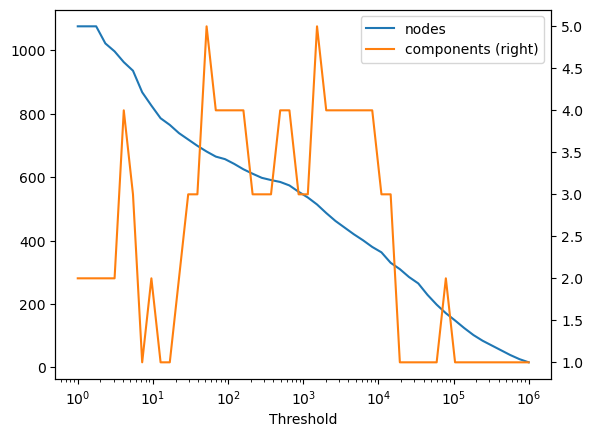

In [37]:
global_threshold_container = {}

for threshold in np.logspace(0,6,50):
    
    global_threshold_container[threshold] = {}
    
    airports_copy = nx.DiGraph()

    for i,j,d in airports_g.edges(data=True):
        if d['Passengers'] > threshold:
            airports_copy.add_edge(i,j)
            
    global_threshold_container[threshold]['nodes'] = airports_copy.number_of_nodes()
    global_threshold_container[threshold]['components'] = len(list(nx.components.connected_components(airports_copy.to_undirected())))

ax = pd.DataFrame(global_threshold_container).T.plot(secondary_y='components')
ax.set_xscale('log')
ax.set_xlabel('Threshold')

A second strategy filters out the weakest edges specific to each node. For example, compare two nodes: 
* X with edges with weights {50,80,90,120} 
* Y with edges with weigths {5,8,9,12}

Under a global thresholding strategy with a cut-off at weight 20, node Y would lose all its connections while node X would keep all of its.

A "disparity filter" would allow different nodes to have a common significance values but different thresholds. Such a filter might allow X to keep 90 and 120 and Y to keep 9 and 12.

In [38]:
def extract_backbone(g, weight='weight', alpha=.05):
    backbone_graph = nx.Graph()
    for node in g:
        k_n = len(g[node])
        if k_n > 1:
            sum_w = sum( g[node][neighbor][weight] for neighbor in g[node] )
            for neighbor in g[node]:
                edge_weight = g[node][neighbor][weight]
                pij = float(edge_weight)/sum_w
                if (1-pij)**(k_n-1) < alpha: # equation 2
                    backbone_graph.add_edge( node,neighbor, weight = edge_weight)
    return backbone_graph

In [39]:
disparity_g = extract_backbone(airports_g.to_undirected(),'Passengers',.05)
print(node_edge_s.format(airports_g.number_of_nodes(),airports_g.number_of_edges()))
print(node_edge_s.format(disparity_g.number_of_nodes(),disparity_g.number_of_edges()))

There are 1,102 nodes and 21,296 edges in the network.
There are 649 nodes and 2,173 edges in the network.


In [40]:
nx.write_gexf(disparity_g,'airline_disparity.gexf')

Again, what's the right alpha value to choose?

Text(0.5, 0, 'alpha')

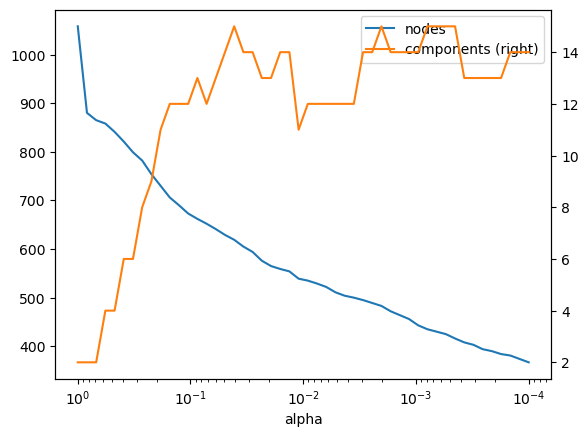

In [41]:
global_threshold_container = {}

for threshold in np.logspace(-4,0,50):
    
    global_threshold_container[threshold] = {}

    _backbone = extract_backbone(airports_g, weight = 'Passengers', alpha = threshold)
            
    global_threshold_container[threshold]['nodes'] = _backbone.number_of_nodes()
    global_threshold_container[threshold]['components'] = len(list(nx.components.connected_components(_backbone.to_undirected())))
    
ax = pd.DataFrame(global_threshold_container).T.plot(secondary_y='components')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('alpha')

## Appendix

### Airport traffic

In [ ]:
# https://www.bts.gov/browse-statistical-products-and-data/bts-publications/data-bank-28ds-t-100-domestic-segment-data
db28_df = pd.read_csv('db28.txt',sep="|",header=None)

# Relabel columns to be compatible with:
# https://www.bts.gov/sites/bts.dot.gov/files/docs/explore-topics-and-geography/topics/airlines-and-airports/230176/reference-file-db28-segment-data-product.pdf
db28_df.columns = range(1,len(db28_df.columns)+1)

# Filter to Passenger flights
pass_df = db28_df[db28_df[18] == 1]

# Groupby origin and destination airports, aggregate by number of passengers
pass_df = pass_df.groupby([6,10]).agg({23:'sum'}).reset_index()

# Rename columns
pass_df.columns = ['Origin','Destination','Passengers']

# Filter to non-zero passengers
pass_df = pass_df[pass_df['Passengers'] > 0]

# Write out
pass_df.to_csv('2022_airport_traffic.csv',index=False)

# Inspect
pass_df.head()

### SP500

In [ ]:
import pandas_datareader as pdr
import yfinance as yf
yf.pdr_override()

idx = pd.IndexSlice

In [ ]:
symbols = requests.get('https://github.com/datasets/s-and-p-500-companies/raw/master/data/constituents_symbols.txt').text
symbols_l = symbols.split('\n')

In [ ]:
pdr.data.get_data_yahoo()

In [ ]:
sp500_d = {}

sp500_data = pdr.data.get_data_yahoo(
    ' '.join(symbols_l).strip(),
    start = '2021-11-01',
    end = '2022-11-02'
)

# for s in symbols_l:
#     try:
#         sp500_d[s] = yf.

In [ ]:
sp500_data.loc[:,'Adj Close'].to_csv('sp500_closes.csv')